## Week 12 Homework (10)




### Q1: define

- Gaussian Processes (GPs) and stochastic processes generally

A stochastic process is a collection of random variables indexed by time or space, which represents the evolution of a system under some uncertainty. This is a framework for modeling functions or data that evolve or fluctuate. A Gaussian Process (GP) is a specific type of stochastic process where every finite subset of the random variables follows a multivariate normal distribution; therefore, any collection of function evaluations from a GP is jointly normal/Gaussian.

GPs are nonparametric, meaning they define a distribution over functions rather than assuming a specific parametric form. A GP is completely specified by a mean function m(x) and a covariance (kernel) function k(x,x'), which together determine the expected value and structure of the functions. The kernel function encodes inductive bias and controls how inputs relate to one another; for example, nearby inputs may produce similar outputs under a smooth kernel. This specification allows for flexible modelling for regression and other tasks, especially when we want uncertainty quantification and don't want to commit to a fixed number of parameters or components.

- Variational inference using the Evidence Lower Bound (ELBO)

Variational inference is a method for approximating posterior distributions that cannot be computed directly. Instead of sampling, the method treates inference as an optimization problem: it takes a simpler, paramaterized family of distributions and tries to find the member of this family that is closest to the true posterior. This is achieved by maximizing the Evidence Lower Bound (ELBO), which provides a lower bound on the marginal likelihood or evidence of the observed data. Maximizing the ELBO simultaneously encourages the approximate posterior to fit the likelihood (to explain the data well) and to stay close to the prior (to penalize comlexity).

Similar to metrics like WAIC and DIC, variational inference with ELBO balances model fit and complexity, and in practice can scale to large datasets where MCMC is not as practical. Variational inference provides a computationally efficient way to approximate posteriors, which is useful for deep probabilistic models like Bayesian neural networks or Gaussian process regression.

### Q2: more GPs

> Repurpose PyMC documentation to provide a demonstration of Gaussian processes for a different dataset context than the PyMC examples.

The code below models electricity usage data (synthetic) over 100 days using GPs, following the PyMC documentation provided [here](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-Marginal.html). First, I used the marginal likelihood approach, where the latent function values are analytically integrated out, which lets us infer values for the GP hyperparameters (ell, eta, and sigma) via sampling. Next, I applied the .conditional method to compute the posterior distribution of the latent function at new input points (X_new), visualizing multiple posterior draws to capture uncertainty in the function estimate. Finally, I used the .predict() method to calculate the posterior predictive mean and variance at those new inputs, based on a single posterior sample, and visualized the mean function along with its 95% credible interval. Together, these steps demonstrate flexible GP regression with uncertainty quantification.

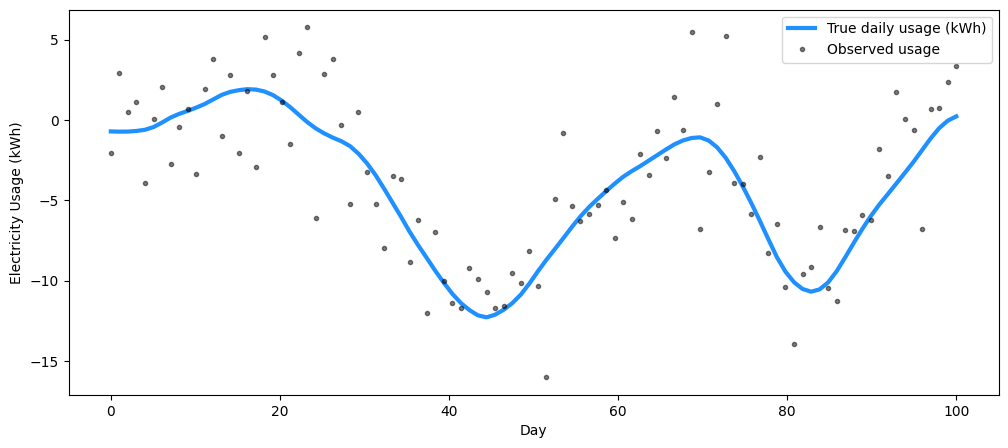

In [2]:
# Context: Simulate daily electricity usage over 100 days with marginal likelihood

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy as sp

%matplotlib inline

# Seed for reproducibility
np.random.seed(1)

n = 100  # Number of days
X = np.linspace(0, 100, n)[:, None]  # Days as input (reshape for GP)

# Simulate the "true" electricity usage pattern (in kWh/day)
ell_true = 15.0             # Lengthscale: daily usage changes gradually
eta_true = 5.0              # Amplitude: variability in usage
cov_func = eta_true**2 * pm.gp.cov.Matern52(1, ell_true)
mean_func = pm.gp.mean.Zero()

# True latent usage function
f_true = np.random.multivariate_normal(
    mean_func(X).eval(), cov_func(X).eval() + 1e-8 * np.eye(n), 1
).flatten()

# Add observational noise (e.g. meter variability, weather)
sigma_true = 3.0
y = f_true + sigma_true * np.random.randn(n)

# Plot
fig = plt.figure(figsize=(12, 5))
ax = fig.gca()
ax.plot(X, f_true, "dodgerblue", lw=3, label="True daily usage (kWh)")
ax.plot(X, y, "ok", ms=3, alpha=0.5, label="Observed usage")
ax.set_xlabel("Day")
ax.set_ylabel("Electricity Usage (kWh)")
plt.legend();

In [9]:
with pm.Model() as model:
    ell = pm.Gamma("ell", alpha=2, beta=0.1)
    eta = pm.HalfCauchy("eta", beta=5)

    cov = eta**2 * pm.gp.cov.Matern52(1, ell)
    gp = pm.gp.Marginal(cov_func=cov)

    sigma = pm.HalfCauchy("sigma", beta=5)
    y_ = gp.marginal_likelihood("y", X=X, y=y, sigma=sigma)

    marginal_post = pm.sample(500, tune=2000, chains=1)


Output()

In [10]:
summary = az.summary(marginal_post, var_names=["ell", "eta", "sigma"], round_to=2, kind="stats")
summary["True value"] = [ell_true, eta_true, sigma_true]
summary


,mean,sd,hdi_3%,hdi_97%,True value
ell,14.37,3.60,9.04,21.89,15.0
eta,6.32,2.05,3.66,10.34,5.0
sigma,2.90,0.23,2.54,3.34,3.0


Output()

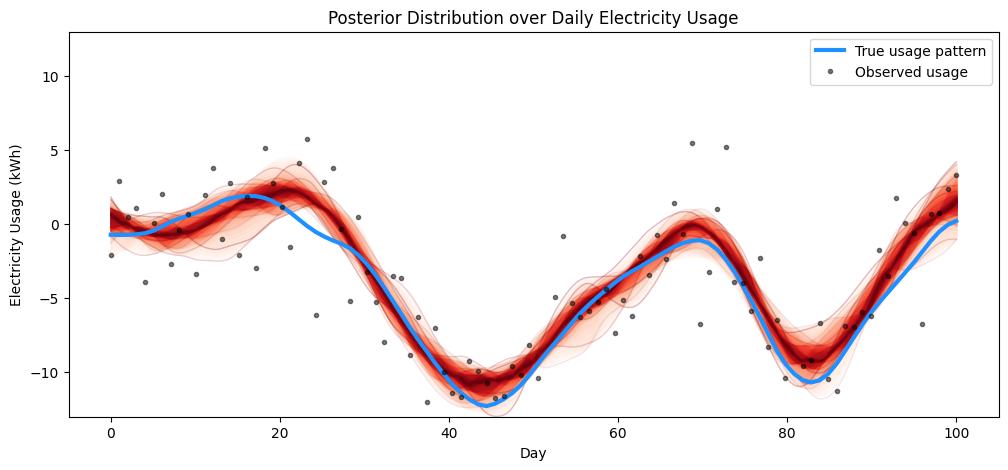

In [11]:
# Posterior Distribution of Electricity Usage (via .conditional)

# Predict electricity usage on new days
X_new = np.linspace(0, 100, 300)[:, None]  # Predict every ~0.3 day

# Add conditional GP to model at new inputs
with model:
    f_pred = gp.conditional("f_pred", X_new)

# Sample from posterior predictive using a few draws (to avoid clutter)
with model:
    pred_samples = pm.sample_posterior_predictive(
        marginal_post.sel(draw=slice(0, 20)), var_names=["f_pred"]
    )

# Plot the posterior distribution over the latent function
fig = plt.figure(figsize=(12, 5))
ax = fig.gca()

from pymc.gp.util import plot_gp_dist
f_pred_samples = az.extract(pred_samples, group="posterior_predictive", var_names=["f_pred"])
plot_gp_dist(ax, samples=f_pred_samples.T, x=X_new)

# Plot the true function and noisy observed data
plt.plot(X, f_true, "dodgerblue", lw=3, label="True usage pattern")
plt.plot(X, y, "ok", ms=3, alpha=0.5, label="Observed usage")

plt.xlabel("Day")
plt.ylabel("Electricity Usage (kWh)")
plt.ylim([-13, 13])
plt.title("Posterior Distribution over Daily Electricity Usage")
plt.legend();



Output()

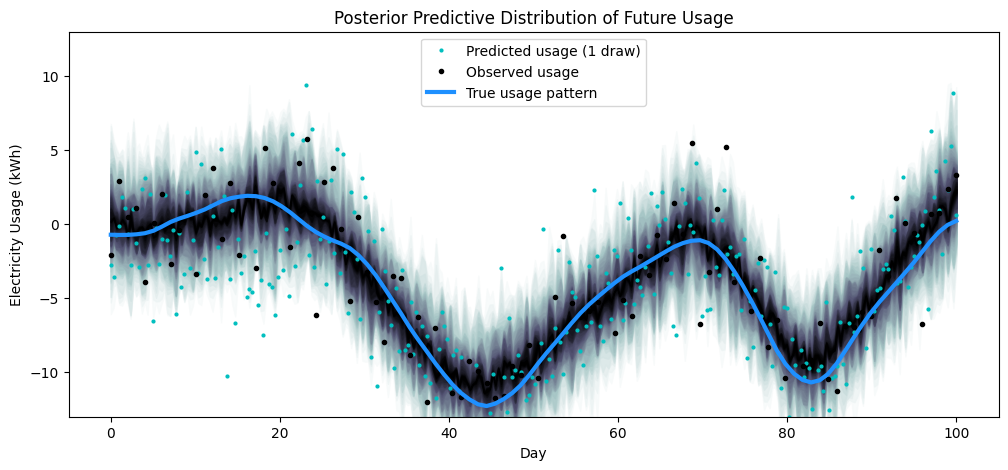

In [12]:
# Sample predictive distribution of future observed usage (latent f + noise)
with model:
    y_pred = gp.conditional("y_pred", X_new, pred_noise=True)
    y_samples = pm.sample_posterior_predictive(
        marginal_post.sel(draw=slice(0, 50)), var_names=["y_pred"]
    )

# Plot
fig = plt.figure(figsize=(12, 5))
ax = fig.gca()

# Extract posterior predictive draws
y_pred_samples = az.extract(y_samples, group="posterior_predictive", var_names=["y_pred"])

# Plot predictive distribution (noisy observations)
plot_gp_dist(ax, y_pred_samples.T, X_new, plot_samples=False, palette="bone_r")

# Show one possible future trajectory
plt.plot(X_new, y_pred_samples.isel(sample=1), "co", ms=2, label="Predicted usage (1 draw)")

# Plot original observations and true function
plt.plot(X, y, "ok", ms=3, alpha=1.0, label="Observed usage")
plt.plot(X, f_true, "dodgerblue", lw=3, label="True usage pattern")

plt.xlabel("Day")
plt.ylabel("Electricity Usage (kWh)")
plt.ylim([-13, 13])
plt.title("Posterior Predictive Distribution of Future Usage")
plt.legend();


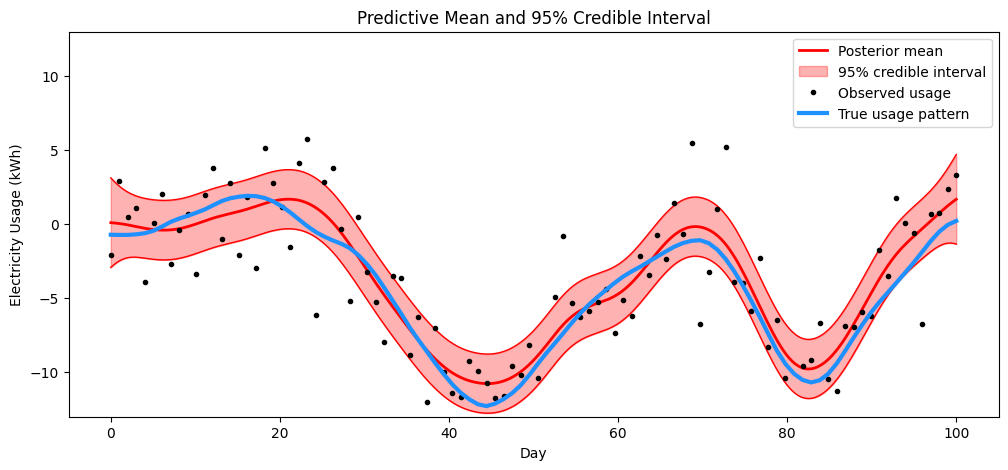

In [17]:
# Predictive Mean and 2σ Interval for Electricity Usage

# Extract one posterior sample and format as point dictionary
posterior_df = marginal_post.posterior.to_dataframe().reset_index()
point_dict = posterior_df.iloc[0][["ell", "eta", "sigma"]].to_dict()

# Predict the posterior mean and variance
with model:
    mu, var = gp.predict(X_new, point=point_dict, diag=True)

sd = np.sqrt(var)

# Plot the predictive mean and 95% interval
fig = plt.figure(figsize=(12, 5))
ax = fig.gca()

plt.plot(X_new, mu, "r", lw=2, label="Posterior mean")
plt.plot(X_new, mu + 2 * sd, "r", lw=1)
plt.plot(X_new, mu - 2 * sd, "r", lw=1)
plt.fill_between(X_new.flatten(), mu - 2 * sd, mu + 2 * sd, color="r", alpha=0.3, label="95% credible interval")

plt.plot(X, y, "ok", ms=3, alpha=1.0, label="Observed usage")
plt.plot(X, f_true, "dodgerblue", lw=3, label="True usage pattern")

plt.xlabel("Day")
plt.ylabel("Electricity Usage (kWh)")
plt.ylim([-13, 13])
plt.title("Predictive Mean and 95% Credible Interval")
plt.legend();


### Q3: more VI/ELBO

> Repurpose PyMC documentation to provide a demonstration of a neural network fit with variational inference for a different dataset context than the PyMC examples.

The code trains a Bayesian neural network using variational inference to classify electricity usage (high vs low) based on two input features: temperature and hour of day, repurposing [PyMC documentation](https://www.pymc.io/projects/examples/en/latest/variational_inference/bayesian_neural_network_advi.html). The training process involved normalizing the data, constructing a neural network with two hidden layers, and fitting the mode. The ELBO convergence plot indicates stable optimization, and the model achieved a decision boundary that reasonably separated the two classes on the test set. However, the predictions were not perfect, which is expected given the noisy nature of the synthetic data and overlapping feature distributions between classes. To further analyze model behavior, we visualized the posterior predictive mean across a 2D input grid and observed a smooth transition in class probabilities, aligning with the boundary learned by the model. Uncertainty was highest along this boundary, demonstrating that the model appropriately quantifies predictive confidence; there were fairly large amount of uncertainty in general in the final map and trace plots. This highlights an advantage of the approach in that it provides not just point predictions but also insight into model confidence and parameter variability.



In [53]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ---- Step 1: Generate Synthetic Data ----
n = 1000
rng = np.random.default_rng(42)
temperature = rng.uniform(-10, 40, n)
hour = rng.uniform(0, 23, n)

# Synthetic electricity usage rule (nonlinear)
usage_prob = 1 / (1 + np.exp(-(0.1 * temperature + np.sin(hour / 3) - 2)))
usage = rng.binomial(1, usage_prob)

X = np.column_stack([temperature, hour])
Y = usage.astype("int32")

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# ---- Step 2: Normalize Inputs ----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


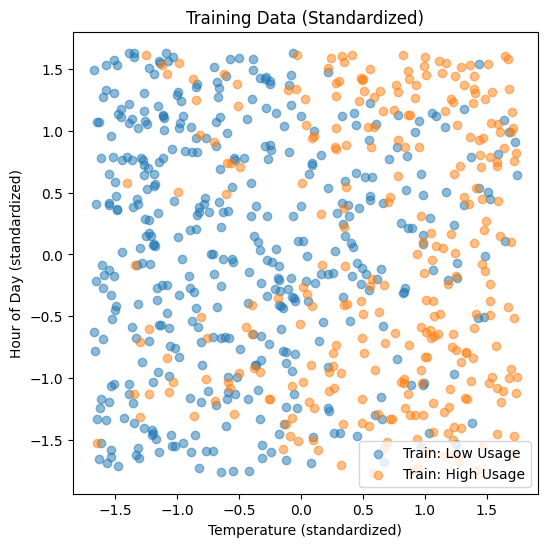

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], label="Train: Low Usage", alpha=0.5)
plt.scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], label="Train: High Usage", alpha=0.5)
plt.xlabel("Temperature (standardized)")
plt.ylabel("Hour of Day (standardized)")
plt.title("Training Data (Standardized)")
plt.legend()


In [56]:
def construct_nn(batch_size=50, n_hidden=20):
    init_1 = rng.standard_normal((X_train.shape[1], n_hidden))
    init_2 = rng.standard_normal((n_hidden, n_hidden))
    init_out = rng.standard_normal(n_hidden)

    coords = {
        "hidden_layer_1": np.arange(n_hidden),
        "hidden_layer_2": np.arange(n_hidden),
        "train_cols": np.arange(X_train.shape[1]),
        "obs_id": np.arange(X_train.shape[0]),
    }

    with pm.Model(coords=coords) as model:
        X_data = pm.Data("X_data", X_train)
        Y_data = pm.Data("Y_data", Y_train)

        ann_input, ann_output = pm.Minibatch(X_data, Y_data, batch_size=batch_size)

        w_in_1 = pm.Normal("w_in_1", 0, 1, initval=init_1, dims=("train_cols", "hidden_layer_1"))
        w_1_2 = pm.Normal("w_1_2", 0, 1, initval=init_2, dims=("hidden_layer_1", "hidden_layer_2"))
        w_2_out = pm.Normal("w_2_out", 0, 1, initval=init_out, dims="hidden_layer_2")

        act_1 = pm.math.tanh(pm.math.dot(ann_input, w_in_1))
        act_2 = pm.math.tanh(pm.math.dot(act_1, w_1_2))
        act_out = pm.math.sigmoid(pm.math.dot(act_2, w_2_out))

        out = pm.Bernoulli("out", p=act_out, observed=ann_output, total_size=X_train.shape[0])

    return model


In [57]:
model = construct_nn()
with model:
    approx = pm.fit(60_000, method="advi")


Output()

Text(0.5, 1.0, 'ELBO Convergence')

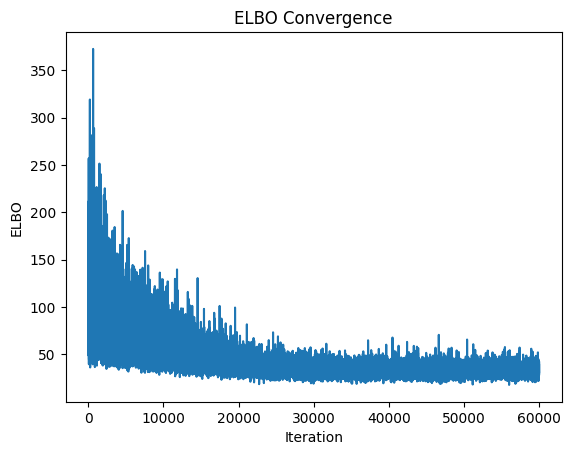

In [59]:
plt.plot(approx.hist)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("ELBO Convergence")

In [60]:
trace = approx.sample(1000)

def sample_posterior_predictive(X_eval, Y_eval, trace, n_hidden=20):
    coords = {
        "hidden_layer_1": np.arange(n_hidden),
        "hidden_layer_2": np.arange(n_hidden),
        "train_cols": np.arange(X_eval.shape[1]),
        "obs_id": np.arange(X_eval.shape[0]),
    }

    with pm.Model(coords=coords):
        ann_input = X_eval
        ann_output = Y_eval

        w_in_1 = pm.Flat("w_in_1", dims=("train_cols", "hidden_layer_1"))
        w_1_2 = pm.Flat("w_1_2", dims=("hidden_layer_1", "hidden_layer_2"))
        w_2_out = pm.Flat("w_2_out", dims="hidden_layer_2")

        act_1 = pm.math.tanh(pm.math.dot(ann_input, w_in_1))
        act_2 = pm.math.tanh(pm.math.dot(act_1, w_1_2))
        act_out = pm.math.sigmoid(pm.math.dot(act_2, w_2_out))

        out = pm.Bernoulli("out", p=act_out, observed=ann_output)

        return pm.sample_posterior_predictive(trace, return_inferencedata=False)

ppc = sample_posterior_predictive(X_test.astype("float64"), Y_test, trace)


Output()

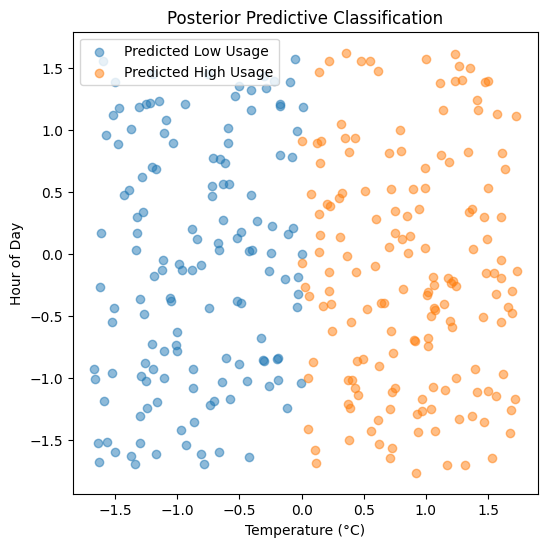

In [61]:
pred_mean = ppc["out"].mean(axis=(0, 1))
pred = pred_mean > 0.5

plt.figure(figsize=(6, 6))
plt.scatter(X_test[pred == 0][:, 0], X_test[pred == 0][:, 1], label="Predicted Low Usage", alpha=0.5)
plt.scatter(X_test[pred == 1][:, 0], X_test[pred == 1][:, 1], label="Predicted High Usage", alpha=0.5)
plt.xlabel("Temperature (°C)")
plt.ylabel("Hour of Day")
plt.title("Posterior Predictive Classification")
plt.legend();


Output()

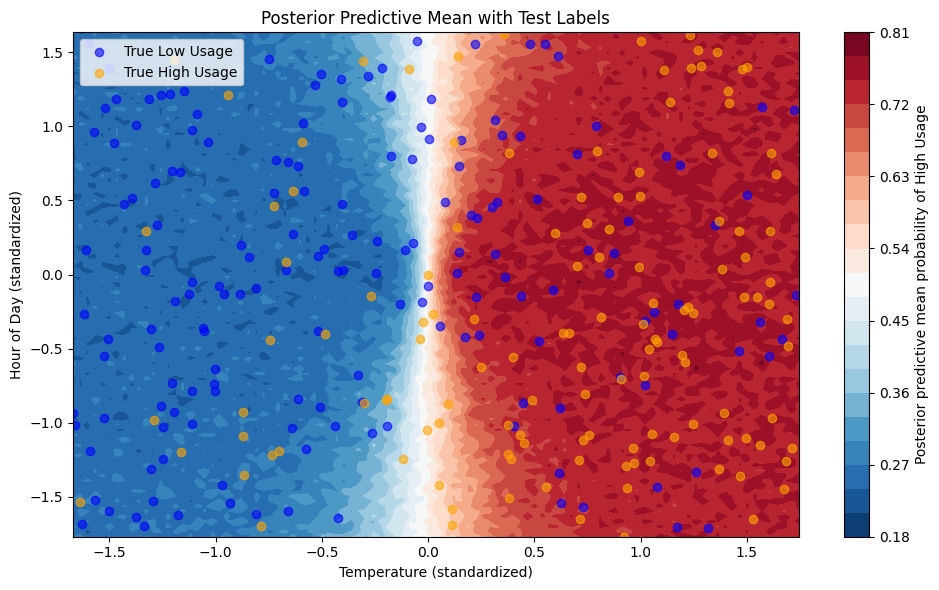

In [62]:
# Posterior Predictive Mean with Test Data Overlay

# Generate grid in standardized feature space
temp_vals = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
hour_vals = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 100)
temp_grid, hour_grid = np.meshgrid(temp_vals, hour_vals)
X_grid = np.c_[temp_grid.ravel(), hour_grid.ravel()]
Y_dummy = np.ones(X_grid.shape[0], dtype="int32")

# Sample predictions over the grid
ppc_grid = sample_posterior_predictive(X_grid.astype("float64"), Y_dummy, trace)

# Compute posterior mean probability
mean_probs = ppc_grid["out"].mean(axis=(0, 1)).reshape(temp_grid.shape)

# Plot: posterior mean probability with test data
plt.figure(figsize=(10, 6))
contour = plt.contourf(temp_grid, hour_grid, mean_probs, levels=20, cmap="RdBu_r")
plt.colorbar(contour, label="Posterior predictive mean probability of High Usage")

# Overlay test data
plt.scatter(X_test[Y_test == 0][:, 0], X_test[Y_test == 0][:, 1], color="blue", label="True Low Usage", alpha=0.6)
plt.scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], color="orange", label="True High Usage", alpha=0.6)

plt.xlabel("Temperature (standardized)")
plt.ylabel("Hour of Day (standardized)")
plt.title("Posterior Predictive Mean with Test Labels")
plt.legend()
plt.tight_layout()


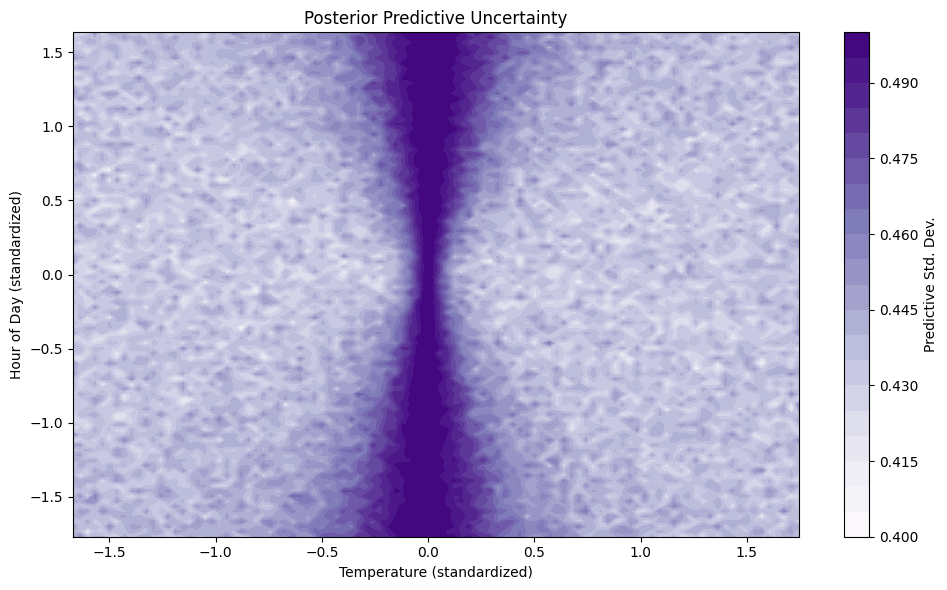

In [63]:
# Uncertainty Contour Plot

# Compute predictive standard deviation (uncertainty)
std_probs = ppc_grid["out"].std(axis=(0, 1)).reshape(temp_grid.shape)

# Plot: predictive uncertainty over grid
plt.figure(figsize=(10, 6))
contour = plt.contourf(temp_grid, hour_grid, std_probs, levels=20, cmap="Purples")
plt.colorbar(contour, label="Predictive Std. Dev.")

plt.xlabel("Temperature (standardized)")
plt.ylabel("Hour of Day (standardized)")
plt.title("Posterior Predictive Uncertainty")
plt.tight_layout()


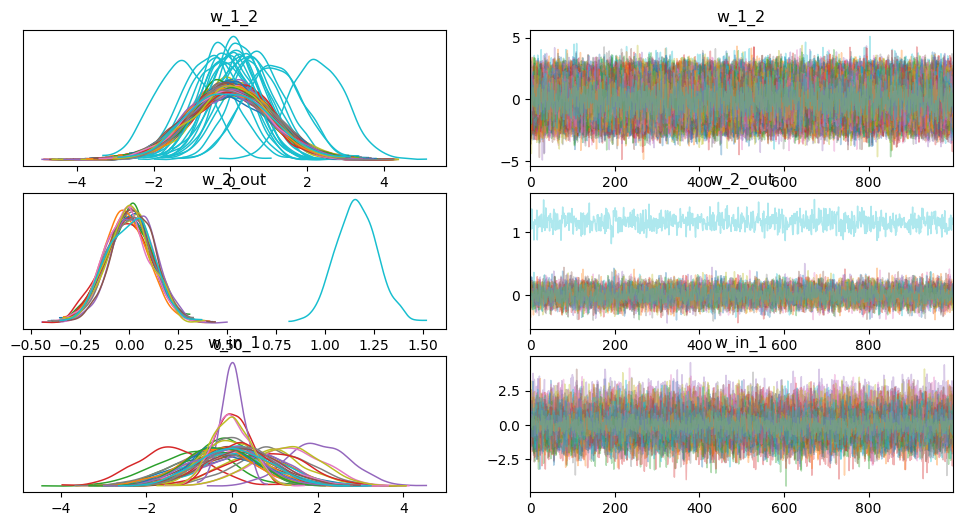

In [65]:
az.plot_trace(trace);